This notebook describes the classification part of the PORT-EK pipeline on the "bat" data set from [reference to our paper]. The enriched k-mer count matrix, along with host spieces labels, are used to preict the most likely host of a viral genomic sequence. 
To use this notebook you will need the count matrix saved as output/deer/15mer_counts_for_classifier.csv generated by running notebooks/bat_analysis.ipynb notebook.

In [1]:
import sys
import pathlib
import json
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, multilabel_confusion_matrix, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


#adding portek source directory to sys path before importing
portek_path = "../portek"
sys.path.insert(0,portek_path)
import portek

pd.options.mode.copy_on_write = True

2024-12-19 15:06:38.567926: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-19 15:06:38.595030: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-19 15:06:39.244695: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


1. Define data set specific values

In [2]:
PLOT_CMAP = {
    "bat": ("#870f7e", 1),
    "bat over-represented": ("#870f7e", 1),
    "deer": ("#ffa401", 1), 
    "deer over-represented": ("#ffa401", 1)
}
k=15

2. Import counts, separate features and labels

In [3]:
counts = pd.read_csv("../output/bat_vs_deer/15mer_counts_for_classifier.csv", index_col=0)
kmer_group = counts.loc['group'].drop('host')
counts.drop('group', inplace=True)
X = counts.drop('host',axis=1).astype(float)
y = counts['host'].astype(float)


/tmp/ipykernel_1214417/289777195.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,26

3. Calculate k-mer count correlation and select only linearily independant k-mers. This may take a long time, depending on the number of initial k-mers.

In [4]:
#Calculate k-mer count correlation matrix
X_corr = X.corr()
print("Done calculating k-mer count corrrelation.")

#Construct a graph where nodes represent k-mers and edges connect k-mers with count correlation coefficient of more than 0.9 
features_list = list(X_corr.columns)
edge_list = set()
for i in range(1,len(features_list)):
    print(i, end='\r',flush=True)
    k1 = features_list[i]
    for j in range(i):
        k2 = features_list[j]
        if abs(X_corr.loc[k1,k2] > 0.9):
            edge = (k1,k2)
            edge_list.add(edge)
corr_graph = nx.Graph(edge_list)
del edge_list

#For large k-mers sets, you may want to delete the correlation matrix to save memory.
#Note that this will prevent you from generating a correlation clustermap.
#To do this, uncomment the following line.
del X_corr

print("Done constructing correlation graph.")

#Calculate count correlation with host label for each k-mer
y_corr_dict={}
y_corr_abs_dict={}
for kmer in corr_graph.nodes:
    y_corr = X[kmer].corr(y)
    y_corr_abs = abs(y_corr)
    y_corr_dict[kmer] = y_corr
    y_corr_abs_dict[kmer] = y_corr_abs
nx.set_node_attributes(corr_graph, y_corr_dict,"y_corr")
nx.set_node_attributes(corr_graph, y_corr_abs_dict,"y_corr_abs")

#Seperate correlated k-mer groups
corr_groups = [corr_graph.subgraph(c).copy() for c in nx.connected_components(corr_graph)]
print(f"There are {len(corr_groups)} groups of k-mers with highly correlated counts.")

#List k-mer missing from the graph, i.e. not correlated with any other k-mer
indep_kmers = [kmer for kmer in features_list if kmer not in corr_graph.nodes]
print(f"There are {len(indep_kmers)} k-mers without highly correlated counts")

#For large k-mers sets, you may want to delete the graph to save memory. Uncomment the following line.
del corr_graph

#From each group of correlated k-mers select the one with the highest correlation of counts with host labels and add to the list of independent k-mers.
for group in corr_groups:
    y_corr_abs = nx.get_node_attributes(group,"y_corr_abs")
    indep_kmers.append(max(y_corr_abs, key=lambda x: y_corr_abs[x]))
del corr_groups

#Extract the count matrix of independent k-mers from the count matrix of all enriched k-mers
X_indep = X.loc[:,indep_kmers]
print(f"{len(X_indep.columns)} linearily independent k-mers selected.")

Done calculating k-mer count corrrelation.
Done constructing correlation graph.
There are 555 groups of k-mers with highly correlated counts.
There are 82 k-mers without highly correlated counts
637 linearily independent k-mers selected.


In [4]:
#Uncomment the following lines as needed to save/load the independent k-mers count matrix and avoid re-calculation of correlation.

# X_indep.to_csv("../output/bat_vs_deer/15mer_indep_counts.csv") 
X_indep = pd.read_csv("../output/bat_vs_deer/15mer_indep_counts.csv", index_col=0)

Optional: plot k-mer counts correlation clustermap and graph. WARNING: make take a long time and a lot of memory, especially for large k-mer sets!

In [5]:
# sns.clustermap(X_corr)

In [6]:
# fig, ax = plt.subplots()
# corr_pos = nx.nx_agraph.graphviz_layout(corr_graph, prog="neato")
# colors = [corr_graph.nodes[node]["y_corr"] for node in list(corr_graph.nodes())]
# nx.draw(corr_graph, pos=corr_pos, node_size=10, node_color=colors, cmap='magma', with_labels=False, width=0.2)
# fig.set_size_inches(10,5)
# fig.set_dpi(600)
# ax.set_title("K-mer count correlation network")
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="magma", norm=plt.Normalize(min(colors),max(colors))), ax=ax, shrink = 0.85)
# cbar.set_label("K-mer count - host label correlation coefficient", rotation=270, labelpad=15)
# plt.show()

4. Calculate k-mer importances acording to MDI and premutation importance, using a random forest classifier.

In [5]:
#Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X_indep,y, test_size=0.3, stratify=y, random_state=14)

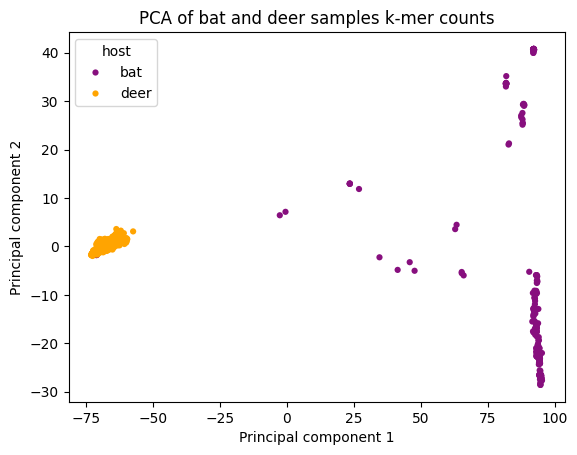

In [6]:
#Perform and plot PCA 
y_names = y.map(lambda y: "bat" if y == 1.0 else "deer")

pca = PCA(2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots()
ax.set_title('PCA of bat and deer samples k-mer counts')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_names, palette=PLOT_CMAP,s=20, linewidth = 0, alpha = 1)

#Uncomment the following line to save the plot as svg.
plt.savefig("../output/bat_vs_deer/PCA.svg", dpi = 600, format = "svg", bbox_inches='tight')

In [10]:
deer_like = np.asarray((X_pca[:,0]>-25) & (X_pca[:,0]<15)).nonzero()

In [8]:
bat_big_cluster = np.asarray((X_pca[:,0]>75) & (X_pca[:,1]<0)).nonzero()
deer_cluster = np.asarray((X_pca[:,0]<-50)).nonzero()

In [14]:
counts.iloc[deer_cluster[0],:][counts["host"] == 1]

/tmp/ipykernel_1214417/391075664.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  counts.iloc[deer_cluster[0],:][counts["host"] == 1]


,AAAGAAAAAGACTGA,AAAAGAAAAAGACTG,CGTCCGGGTGTGACC,ATGACCCAAATGTAC,ACACAATCGACGGCT,GACCCAAATGTACAA,CACACAATCGACGGC,TGACCCAAATGTACA,CACAATCGACGGCTC,TTCGTCCGGGTGTGA,...,GTCTGATAATGGACC,ATAGCAATCTTTAAT,TCTCTTGTAGATCTG,ATCTCTTGTAGATCT,AAATGTCTGATAATG,ACGAACATGAAAATT,ACATAGCAATCTTTA,AATGTCTGATAATGG,CATAGCAATCTTTAA,host
bat_OM995891.1,0,0,1,0,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,1,1
bat_OM995890.1,0,0,1,0,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,1,1


In [11]:
deer_like[0]

array([405, 428])

In [38]:
X_pca[405]

array([-0.49766005,  7.14944073])

In [14]:
X_pca[428]

array([-2.63039084,  6.43685355])

In [41]:
X_pca[222]

array([-71.49460401,  -1.45939747])

In [54]:
counts.iloc[428,:]

AAAGAAAAAGACTGA    0
AAAAGAAAAAGACTG    0
CGTCCGGGTGTGACC    1
ATGACCCAAATGTAC    1
ACACAATCGACGGCT    0
                  ..
ACGAACATGAAAATT    1
ACATAGCAATCTTTA    1
AATGTCTGATAATGG    1
CATAGCAATCTTTAA    1
host               1
Name: bat_MZ081381.1, Length: 32459, dtype: object

Lower left from deer-like pair - MZ081381.1  - RpYN06 -2.6 6.4
Upper right from deer-like pair - MN996532.2 - RaTG13 -0.5 7.2

example from lower right big bat cluster - OR233320.1 - Rt22QT48 93.2, -17.7
example from deer cluster - EPI_ISL_16318391 -71.5 -1.5

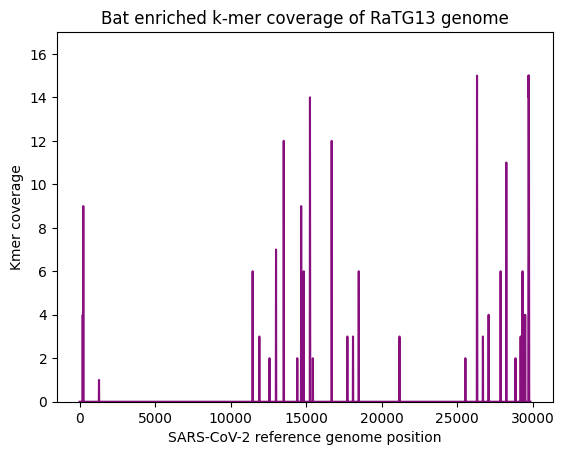

In [53]:
def kmer_coverage_of_genome(sample_name:str, kmer_groups:pd.Series) -> pd.DataFrame:
    in_path = f"../output/bat_vs_deer/15mer_indices/{sample_name}.json"
    with open(in_path, mode = "r") as in_file:
        temp_dict = json.load(in_file)
    pos_dict = {kmer:pos[0] for kmer,pos in temp_dict.items()}
    max_pos = max(pos_dict.values())
    kmer_coverage_n = pd.DataFrame(
        0, index=range(1, max_pos+k+1), columns=["n_bat_enriched", "n_deer_enriched"]
    )
    kmer_coverage_kmer = pd.DataFrame(
        [[[], []] for _ in range(1, max_pos+k+1)],
        index=range(1, max_pos+k+1),
        columns=["bat_enriched", "deer_enriched"],
        dtype="object",
    )
    kmer_coverage = pd.concat([kmer_coverage_n, kmer_coverage_kmer], axis=1)
    for kmer in kmer_groups.index:
        if kmer in pos_dict.keys():
            if kmer_groups[kmer] == "bat over-represented":
                kmer_start = pos_dict[kmer]
                kmer_end = kmer_start+k-1
                kmer_coverage.loc[kmer_start:kmer_end, "n_bat_enriched"] += 1
                kmer_coverage.loc[kmer_start:kmer_end, "bat_enriched"].apply(lambda element: element.append(kmer))
            if kmer_groups[kmer] == "deer over-represented":
                kmer_start = pos_dict[kmer]
                kmer_end = kmer_start+k-1
                kmer_coverage.loc[kmer_start:kmer_end, "n_deer_enriched"] += 1
                kmer_coverage.loc[kmer_start:kmer_end, "deer_enriched"].apply(lambda element: element.append(kmer))

    return kmer_coverage

sample = "bat_MN996532.2"
coverage = kmer_coverage_of_genome(sample, kmer_group)

fig, ax = plt.subplots()
ax.set_title(f"Bat enriched k-mer coverage of RaTG13 genome")
ax.set_xlabel("SARS-CoV-2 reference genome position")
ax.set_ylabel("Kmer coverage")
ax.set_ylim(0,17)
sns.lineplot(x=coverage.index, y=coverage["n_bat_enriched"], color="#870f7e")

plt.savefig("../output/bat_vs_deer/enr_bat_kmer_RaTG13_coverage.svg", dpi = 600, format = "svg")


In [56]:
#perform classification using a simple random forest
rf_imp= RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=14)
rf_imp.fit(X_train,y_train)
y_pred = rf_imp.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       101
         1.0       1.00      1.00      1.00        79

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



In [57]:
imps = pd.DataFrame({'name':rf_imp.feature_names_in_,'importance':rf_imp.feature_importances_}).set_index('name')
perm_imps= permutation_importance(rf_imp, X_test, y_test, scoring='f1', random_state=14)
perm_importances = pd.DataFrame(perm_imps['importances_mean'], index=X_test.columns, columns=['perm_importance'])
com_imp = pd.concat([imps, perm_importances], axis=1).sort_values('importance', ascending=False)

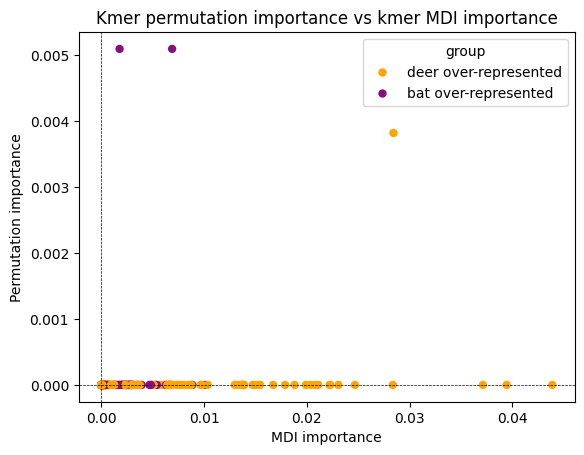

In [58]:
#Plot permutation and MDI importance
fig,ax=plt.subplots()
sns.scatterplot(data = com_imp, x='importance', y='perm_importance', hue=kmer_group, palette=PLOT_CMAP, linewidth = 0)
ax.axhline(0, linestyle='dashed', linewidth=0.5,color='black')
ax.axvline(0, linestyle='dashed', linewidth=0.5,color='black')
ax.set_title('Kmer permutation importance vs kmer MDI importance')
ax.set_xlabel('MDI importance')
ax.set_ylabel('Permutation importance')

#Uncomment the following line to save the plot as svg.
plt.savefig("../output/bat_vs_deer/kmer_feature_importance.svg", dpi = 600, format = "svg")

In [60]:
#Discard unimportant k-mers and redo train/test split.
imp_kmers = com_imp[(com_imp['importance'] >= 0) & (com_imp['perm_importance']>=0)].index
print(f"{len(imp_kmers)} k-mers selected after importance filter.")
X_imp = X_indep.loc[:,imp_kmers]
X_imp_train, X_imp_test, y_train, y_test = train_test_split(X_imp,y, test_size=0.3, stratify=y, random_state=14)

637 k-mers selected after importance filter.


In [64]:
com_imp.sort_values("perm_importance", ascending=False)

,importance,perm_importance
CGTCCGGGTGTGACC,0.006889,0.005096
CTACAAGTTTTGGAC,0.001776,0.005096
TTACAAGTTTTGGAC,0.028435,0.003822
ATGAGAAGTGCTCTG,0.043887,0.000000
GATGCCGTTGTGTGC,0.000000,0.000000
...,...,...
TTCAGTACGGTCGTA,0.000034,0.000000
CTGCTAACTTTTGTG,0.000034,0.000000
CGCGGAGTACGATCG,0.000031,0.000000
AACTGCTTATGCTAA,0.000029,0.000000


5. Classify the samples according to most probable host using various model architectures.

In [13]:
#Calculate class weights
pos_weigth = len(y_train)/len(y_train[y_train == 1])
neg_weigth = len(y_train)/len(y_train[y_train == 0])
print(neg_weigth, pos_weigth)

#Set up and build neural-network.
keras.utils.set_random_seed(14)
N_KMERS = len(X_imp.columns)
HIDDEN_DIMS = [1024,256]
DROPOUT = 0.3
CLASS_WIEGHTS = {0.0:neg_weigth,1.0:pos_weigth}
LEARNING_RATE = 1e-5
N_EPOCHS = 50
BATCH_SIZE = 8

metrics = ['accuracy', keras.metrics.AUC()]
early_stopping = keras.callbacks.EarlyStopping('val_loss', patience=3)
classification_optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE)

def build_nn(input_shape):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    model.add(keras.layers.Dropout(DROPOUT))
    model.add(keras.layers.Dense(units=HIDDEN_DIMS[0],activation='gelu', kernel_constraint=keras.constraints.MaxNorm(3)))
    model.add(keras.layers.Dropout(DROPOUT))
    model.add(keras.layers.Dense(units=HIDDEN_DIMS[1],activation='gelu', kernel_constraint=keras.constraints.MaxNorm(3)))
    model.add(keras.layers.Dropout(DROPOUT))
    model.add(keras.layers.Dense(units=1,activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer = classification_optimizer, metrics=['accuracy'])
    return model

model_nn = build_nn(N_KMERS)

1.7829787234042553 2.277173913043478


2024-12-16 10:03:32.208070: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-16 10:03:32.227493: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-16 10:03:32.227601: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

I0000 00:00:1734339813.017279 2931206 service.cc:145] XLA service 0x7114c0003970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734339813.017299 2931206 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2024-12-16 10:03:33.032920: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-12-16 10:03:33.108622: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1734339814.531066 2931206 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       101
         1.0       1.00      0.99      0.99        79

    accuracy                           0.99       180
   macro avg       1.00      0.99      0.99       180
weighted avg       0.99      0.99      0.99       180



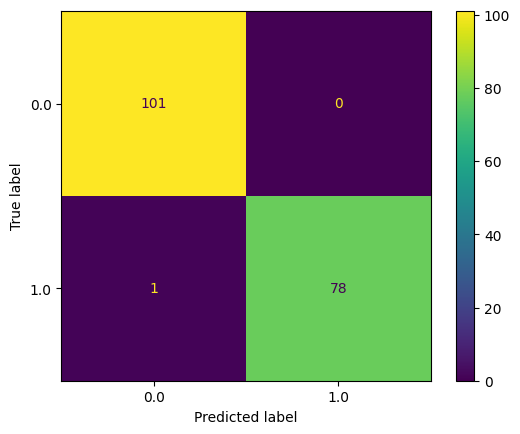

In [14]:
#Train and test neural network
model_nn.fit(X_imp_train,y_train, epochs=N_EPOCHS, batch_size=BATCH_SIZE, class_weight=CLASS_WIEGHTS, validation_split=0.1, callbacks=[early_stopping], verbose=0)

y_score = model_nn.predict(X_imp_test)
y_pred = y_score > 0.5
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       101
         1.0       1.00      1.00      1.00        79

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



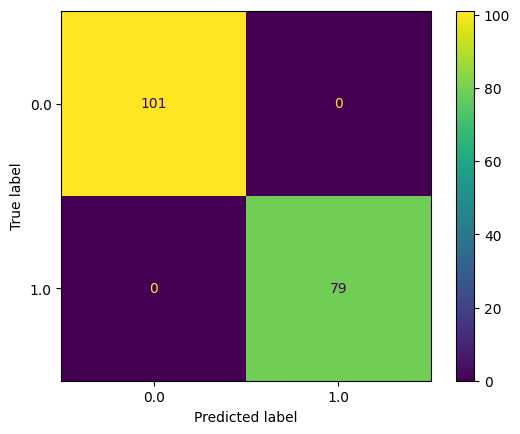

In [15]:
#Train and test random forest
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=14)
model_rf.fit(X_imp_train, y_train)
y_score = model_rf.predict(X_imp_test)
print(classification_report(y_test, y_score))
ConfusionMatrixDisplay.from_predictions(y_test,y_score)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       101
         1.0       1.00      1.00      1.00        79

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



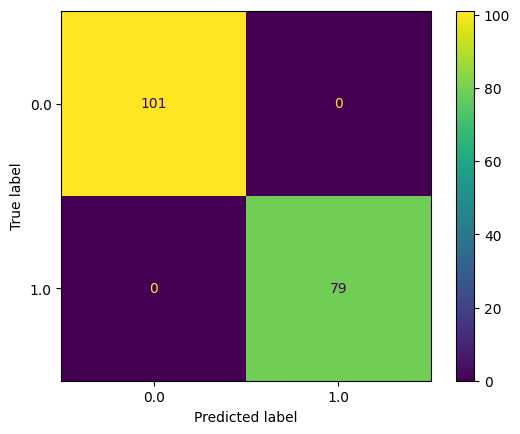

In [16]:
#Train and test ridge regression classifier
model_rc = RidgeClassifier(alpha=1,class_weight='balanced',random_state=14)
model_rc.fit(X_imp_train, y_train)
y_score = model_rc.predict(X_imp_test)
print(classification_report(y_test, y_score))
ConfusionMatrixDisplay.from_predictions(y_test,y_score)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       101
         1.0       1.00      1.00      1.00        79

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



/home/labadmin/repos/PORT-EK/env/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


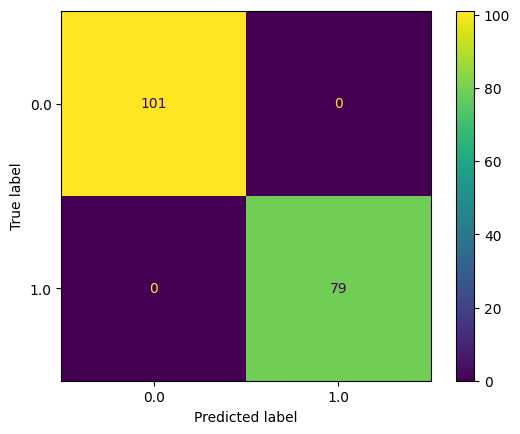

In [17]:
#Train and test linear support vector machine classifier
model_lsvc = LinearSVC(class_weight='balanced',random_state=14)
model_lsvc.fit(X_imp_train, y_train)
y_score = model_lsvc.predict(X_imp_test)
print(classification_report(y_test, y_score))
ConfusionMatrixDisplay.from_predictions(y_test,y_score)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       101
         1.0       1.00      1.00      1.00        79

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



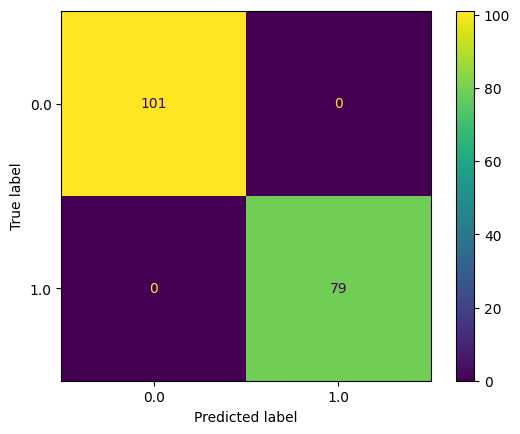

In [18]:
#Train and test gradient boosting classifier
model_gb = GradientBoostingClassifier(n_estimators=100,random_state=14)
model_gb.fit(X_imp_train, y_train)
y_score = model_gb.predict(X_imp_test)
print(classification_report(y_test, y_score))
ConfusionMatrixDisplay.from_predictions(y_test,y_score)

6. Bootstrapping

In [19]:
# Train the neural network on 100 diffrent train/test splits and evaluate (also on OoB data). 
#This helps check if the performance is not an artifact of the previous train/test split.

f1s = []
for i in range(100):
    X_imp_train, X_imp_test, y_train, y_test = train_test_split(X_imp,y, test_size=0.3, stratify=y, random_state=i)
    classification_optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE)
    model_nn_bs = build_nn(N_KMERS)
    model_nn_bs.fit(X_imp_train,y_train, epochs=N_EPOCHS, batch_size=BATCH_SIZE, class_weight=CLASS_WIEGHTS, validation_split=0.1, callbacks=[early_stopping], verbose=0)
    y_score = model_nn_bs.predict(X_imp_test, verbose=0)
    y_pred = y_score > 0.5
    f1s.append(f1_score(y_test, y_pred))
    print(i, end="\r")

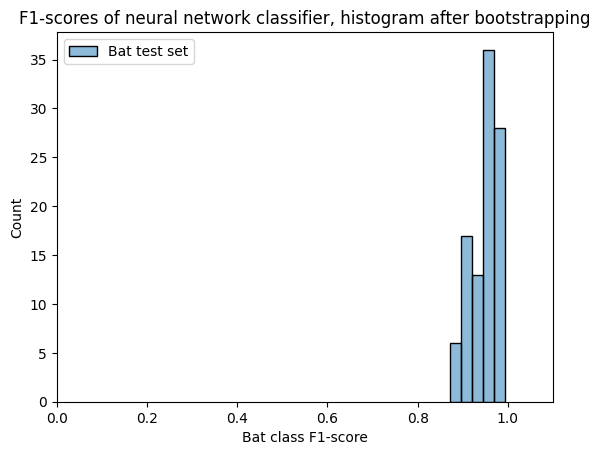

In [20]:
#Plot histograms of f1-scores
fig, ax = plt.subplots()
f1s_df = pd.DataFrame({"Bat test set": f1s})
sns.histplot(f1s_df, bins=5)
ax.set_title("F1-scores of neural network classifier, histogram after bootstrapping")
ax.set_xlim(0,1.1)
ax.set_xlabel("Bat class F1-score")
plt.show()

#Uncomment the following line to save the plot as svg.
fig.savefig("../output/bat_vs_deer/bat_nn_bootstrap.svg", dpi=600, format="svg")